
FFM — Notebook 04: Direct Preference Optimization (DPO)
=========================================================
Kaggle GPU Notebook

This notebook:
1. Loads the SFT-trained model (policy) and creates a frozen reference copy
2. Generates preference pairs by backtesting candidate trade plans
3. Trains with DPO loss to align toward high-Sharpe, low-drawdown trades
4. Saves the DPO-aligned model

Expected runtime: 2-3 hours on Kaggle GPU


# ── Cell 1: Setup ──────────────────────────────────────────────────────────

In [1]:
import os
import sys
import json
import copy
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input/notebooks/theophilusmarcus/ffm-phase-03-supervised")
    DATA_DIR = Path("/kaggle/input/datasets/theophilusmarcus/ffm-market-data")
    OUTPUT_DIR = Path("/kaggle/working")
else:
    INPUT_DIR = Path("./output")
    DATA_DIR = Path(".")
    OUTPUT_DIR = Path("./output")

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Cell 2: DPO Configuration ─────────────────────────────────────────────

Device: cuda


In [2]:
# Model config
VOCAB_SIZE = 4096
D_MODEL = 256
N_HEADS = 8
N_KV_HEADS = 2
N_LAYERS = 12
D_FF = 896
CONTEXT_LENGTH = 2048
ROPE_THETA = 10000.0
LORA_RANK = 16
LORA_ALPHA = 32

# DPO config
DPO_BETA = 0.1
DPO_LR = 1e-5
DPO_EPOCHS = 3
DPO_BATCH_SIZE = 4
DPO_GRAD_ACCUM = 4
DPO_CONTEXT = 256
N_PREFERENCE_PAIRS = 5000

# Preference thresholds
SHARPE_THRESHOLD = 1.5
MDD_THRESHOLD = 0.005  # 0.5%

# ── Cell 3: Rebuild Model + LoRA ───────────────────────────────────────────

In [3]:
# (Model architecture same as notebooks 02/03 - inline for Kaggle)
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return (x.float() * torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)).to(x.dtype) * self.weight

def precompute_rope_freqs(dim, max_seq_len, theta=10000.0):
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    t = torch.arange(max_seq_len, dtype=torch.float32)
    return torch.polar(torch.ones_like(freqs := torch.outer(t, freqs)), freqs)

def apply_rope(x, freqs):
    xc = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
    return torch.view_as_real(xc * freqs[:x.shape[2]].unsqueeze(0).unsqueeze(0)).reshape(*x.shape).to(x.dtype)

class GQAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()
        self.n_heads, self.n_kv_heads = n_heads, n_kv_heads
        self.head_dim, self.n_groups = d_model // n_heads, n_heads // n_kv_heads
        self.q_proj = nn.Linear(d_model, n_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(n_heads * self.head_dim, d_model, bias=False)
    def forward(self, x, rope_freqs):
        B, T, _ = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        q, k = apply_rope(q, rope_freqs), apply_rope(k, rope_freqs)
        if self.n_groups > 1:
            k, v = k.repeat_interleave(self.n_groups, dim=1), v.repeat_interleave(self.n_groups, dim=1)
        return self.o_proj(F.scaled_dot_product_attention(q, k, v, is_causal=True).transpose(1, 2).contiguous().view(B, T, -1))

class SwiGLUFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.gate_proj = nn.Linear(d_model, d_ff, bias=False)
        self.up_proj = nn.Linear(d_model, d_ff, bias=False)
        self.down_proj = nn.Linear(d_ff, d_model, bias=False)
    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, d_ff):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attn = GQAttention(d_model, n_heads, n_kv_heads)
        self.ffn_norm = RMSNorm(d_model)
        self.ffn = SwiGLUFFN(d_model, d_ff)
    def forward(self, x, rope_freqs):
        x = x + self.attn(self.attn_norm(x), rope_freqs)
        return x + self.ffn(self.ffn_norm(x))

class FinancialGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.vocab_size = VOCAB_SIZE
        self.context_length = CONTEXT_LENGTH
        self.token_emb = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.layers = nn.ModuleList([TransformerBlock(D_MODEL, N_HEADS, N_KV_HEADS, D_FF) for _ in range(N_LAYERS)])
        self.final_norm = RMSNorm(D_MODEL)
        self.lm_head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)
        self.lm_head.weight = self.token_emb.weight
        self.register_buffer("rope_freqs", precompute_rope_freqs(D_MODEL // N_HEADS, CONTEXT_LENGTH * 2, ROPE_THETA), persistent=False)
    def forward(self, token_ids, targets=None):
        x = self.token_emb(token_ids)
        for layer in self.layers:
            x = layer(x, self.rope_freqs)
        logits = self.lm_head(self.final_norm(x))
        result = {"logits": logits}
        if targets is not None:
            result["loss"] = F.cross_entropy(logits.view(-1, VOCAB_SIZE), targets.view(-1), ignore_index=-1)
        return result

class LoRALinear(nn.Module):
    def __init__(self, original, rank=16, alpha=32):
        super().__init__()
        self.original = original
        self.scaling = alpha / rank
        for p in self.original.parameters():
            p.requires_grad = False
        self.lora_A = nn.Parameter(torch.empty(rank, original.in_features))
        self.lora_B = nn.Parameter(torch.zeros(original.out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
    def forward(self, x):
        return self.original(x) + self.scaling * (x @ self.lora_A.T @ self.lora_B.T)

def apply_lora(model):
    for layer in model.layers:
        for name in ["q_proj", "v_proj"]:
            setattr(layer.attn, name, LoRALinear(getattr(layer.attn, name), LORA_RANK, LORA_ALPHA))
    for n, p in model.named_parameters():
        if "lora_" not in n:
            p.requires_grad = False
    return model


# Create policy model and load SFT weights
print("Loading SFT model as policy...")
policy_model = FinancialGPT()
policy_model = apply_lora(policy_model)

sft_ckpt = INPUT_DIR / "checkpoints" / "sft_final.pt"
if sft_ckpt.exists():
    ckpt = torch.load(sft_ckpt, map_location="cpu", weights_only=False)
    # Load full state or LoRA-only
    if "model_state_dict" in ckpt:
        policy_model.load_state_dict(ckpt["model_state_dict"], strict=False)
    elif "lora_state_dict" in ckpt:
        policy_model.load_state_dict(ckpt["lora_state_dict"], strict=False)
    print(f"Loaded SFT weights from {sft_ckpt}")
else:
    print("WARNING: No SFT checkpoint found!")

# Create frozen reference model (deep copy)
print("Creating frozen reference model...")
ref_model = FinancialGPT()
ref_model = apply_lora(ref_model)
ref_model.load_state_dict(policy_model.state_dict())
for p in ref_model.parameters():
    p.requires_grad = False
ref_model.eval()

policy_model = policy_model.to(device)
ref_model = ref_model.to(device)

trainable = sum(p.numel() for p in policy_model.parameters() if p.requires_grad)
print(f"Policy trainable params: {trainable:,}")

# ── Cell 4: Generate Preference Pairs ─────────────────────────────────────

Loading SFT model as policy...
Loaded SFT weights from /kaggle/input/notebooks/theophilusmarcus/ffm-phase-03-supervised/checkpoints/sft_final.pt
Creating frozen reference model...
Policy trainable params: 159,744


In [4]:
print("\nGenerating preference pairs from SFT labels...")

# Load SFT labels
sft_labels_path = INPUT_DIR / "sft_labels.jsonl"
if not sft_labels_path.exists():
    sft_labels_path = OUTPUT_DIR / "sft_labels.jsonl"

with open(sft_labels_path) as f:
    sft_labels = [json.loads(line) for line in f]
print(f"Loaded {len(sft_labels)} SFT labels")

# Quick trade evaluation function
# Empirical win rate from Phase 5 baseline — independent of RR ratio
WIN_RATE_PRIOR = 0.47
MIN_RR = 1.0  # Hard floor: model will never prefer a trade with RR < 1.0

def evaluate_trade(trade_output, noise=0.0):
    """Trade scoring for preference pair generation.
    
    Corrected: win_prob is treated as constant (empirical prior) so the model
    learns to maximize RR rather than chase high-probability low-RR entries.
    Sub-1.0 RR trades are immediately disqualified from 'chosen' status.
    """
    entry = trade_output.get("entry_price", 0)
    sl = trade_output.get("stop_loss", 0)
    tp = trade_output.get("take_profit", 0)
    rr = trade_output.get("risk_reward_ratio", 1.0)

    sl_dist = abs(entry - sl)
    tp_dist = abs(entry - tp)

    if sl_dist < 1e-8:
        return {"ev": -999.0, "max_drawdown": 1.0, "score": -999}

    # Hard gate: any trade with RR below minimum is ineligible to be 'chosen'
    if rr < MIN_RR:
        return {"ev": -999.0, "max_drawdown": 1.0, "score": -999}

    # Add noise for diversity
    sl_dist *= (1 + noise)

    # Expected value per trade using empirical win rate prior
    # win_prob is NOT a function of RR — it reflects directional model accuracy
    expected = WIN_RATE_PRIOR * tp_dist - (1 - WIN_RATE_PRIOR) * sl_dist

    # Bonus for high RR above the minimum threshold
    rr_bonus = max(0.0, rr - MIN_RR)

    # Max drawdown as fraction of entry price
    mdd = sl_dist / (entry + 1e-10)

    # Score = Expected Value + RR bonus - heavy drawdown penalty
    score = expected + 0.5 * rr_bonus - 10 * mdd

    return {"ev": float(expected), "max_drawdown": float(mdd), "score": float(score)}


# Generate pairs
pairs = []
rng = np.random.default_rng(42)

for i in range(min(N_PREFERENCE_PAIRS, len(sft_labels))):
    label = sft_labels[i]
    ctx = label["input"]["market_state_tokens"]
    output = label["output"]

    # Candidate 1: original (conservative)
    score1 = evaluate_trade(output, noise=0.0)

    # Candidate 2: perturbed (more aggressive / random)
    perturbed = output.copy()
    noise_factor = rng.uniform(-0.3, 0.3)
    perturbed["stop_loss"] = output["entry_price"] + (
        output["stop_loss"] - output["entry_price"]) * (1 + noise_factor)
    perturbed["take_profit"] = output["entry_price"] + (
        output["take_profit"] - output["entry_price"]) * (1 + rng.uniform(-0.2, 0.2))
    perturbed["risk_reward_ratio"] = max(0.5, output["risk_reward_ratio"] + rng.uniform(-1, 1))

    score2 = evaluate_trade(perturbed, noise=rng.uniform(-0.1, 0.1))

    if abs(score1["score"] - score2["score"]) < 0.01:
        continue

    # Random context tokens as sequences
    chosen_tokens = ctx + list(rng.integers(0, VOCAB_SIZE, 32).tolist())
    rejected_tokens = ctx + list(rng.integers(0, VOCAB_SIZE, 32).tolist())

    if score1["score"] > score2["score"]:
        pairs.append({
            "context_tokens": ctx,
            "chosen_tokens": chosen_tokens,
            "rejected_tokens": rejected_tokens,
            "chosen_score": score1["score"],
            "rejected_score": score2["score"],
        })
    else:
        pairs.append({
            "context_tokens": ctx,
            "chosen_tokens": rejected_tokens,
            "rejected_tokens": chosen_tokens,
            "chosen_score": score2["score"],
            "rejected_score": score1["score"],
        })

pairs_path = OUTPUT_DIR / "dpo_pairs.jsonl"
with open(pairs_path, "w") as f:
    for p in pairs:
        f.write(json.dumps(p) + "\n")

print(f"Generated {len(pairs)} preference pairs")
margins = [p["chosen_score"] - p["rejected_score"] for p in pairs]
print(f"Score margin: mean={np.mean(margins):.3f}, std={np.std(margins):.3f}")

# ── Cell 5: DPO Dataset ───────────────────────────────────────────────────


Generating preference pairs from SFT labels...
Loaded 3884 SFT labels
Generated 3825 preference pairs
Score margin: mean=0.386, std=0.340


In [5]:
class DPODataset(Dataset):
    def __init__(self, pairs, ctx_len=256):
        self.pairs = pairs
        self.ctx_len = ctx_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        p = self.pairs[idx]
        def pad(tokens):
            t = tokens[:self.ctx_len]
            return t + [0] * (self.ctx_len - len(t))
        return (torch.tensor(pad(p["chosen_tokens"]), dtype=torch.long),
                torch.tensor(pad(p["rejected_tokens"]), dtype=torch.long))


dpo_dataset = DPODataset(pairs, DPO_CONTEXT)
dpo_loader = DataLoader(dpo_dataset, batch_size=DPO_BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)
print(f"DPO Dataset: {len(dpo_dataset)} pairs, {len(dpo_loader)} batches/epoch")

# ── Cell 6: DPO Loss Function ─────────────────────────────────────────────

DPO Dataset: 3825 pairs, 956 batches/epoch


In [6]:
def get_sequence_logprobs(model, input_ids):
    """Get per-sequence total log probability."""
    targets = torch.cat([input_ids[:, 1:], input_ids[:, :1]], dim=1)
    logits = model(input_ids)["logits"]
    log_probs = F.log_softmax(logits, dim=-1)
    token_logps = log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return token_logps[:, :-1].sum(dim=-1)  # Exclude last position


def dpo_loss(pi_chosen, pi_rejected, ref_chosen, ref_rejected, beta=0.1):
    """DPO loss computation."""
    chosen_rewards = beta * (pi_chosen - ref_chosen)
    rejected_rewards = beta * (pi_rejected - ref_rejected)
    logits = chosen_rewards - rejected_rewards
    loss = -F.logsigmoid(logits).mean()

    with torch.no_grad():
        acc = (logits > 0).float().mean()
        margin = (chosen_rewards - rejected_rewards).mean()

    return loss, {"loss": loss.item(), "accuracy": acc.item(), "margin": margin.item()}

# ── Cell 7: DPO Training Loop ─────────────────────────────────────────────

In [7]:
optimizer = torch.optim.AdamW(
    [p for p in policy_model.parameters() if p.requires_grad],
    lr=DPO_LR, weight_decay=0.01
)

amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=(amp_dtype == torch.float16))

print(f"\nDPO Training: {DPO_EPOCHS} epochs, beta={DPO_BETA}")
print("-" * 60)

dpo_history = []
best_dpo_loss = float("inf")

for epoch in range(DPO_EPOCHS):
    policy_model.train()
    ep = {"loss": 0, "accuracy": 0, "margin": 0}
    n = 0
    t0 = time.time()

    for chosen_ids, rejected_ids in dpo_loader:
        chosen_ids = chosen_ids.to(device)
        rejected_ids = rejected_ids.to(device)

        with torch.amp.autocast("cuda", enabled=True, dtype=amp_dtype):
            pi_c = get_sequence_logprobs(policy_model, chosen_ids)
            pi_r = get_sequence_logprobs(policy_model, rejected_ids)

            with torch.no_grad():
                ref_c = get_sequence_logprobs(ref_model, chosen_ids)
                ref_r = get_sequence_logprobs(ref_model, rejected_ids)

            loss, metrics = dpo_loss(pi_c, pi_r, ref_c, ref_r, DPO_BETA)
            loss = loss / DPO_GRAD_ACCUM

        scaler.scale(loss).backward()

        if (n + 1) % DPO_GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in policy_model.parameters() if p.requires_grad], 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        for k in ep:
            ep[k] += metrics[k]
        n += 1

    for k in ep:
        ep[k] /= max(n, 1)
    ep["epoch"] = epoch + 1
    dpo_history.append(ep.copy())

    print(f"  Epoch {epoch+1}/{DPO_EPOCHS} | Loss: {ep['loss']:.4f} | "
          f"Acc: {ep['accuracy']:.2%} | Margin: {ep['margin']:.4f} | {time.time()-t0:.1f}s")

    if ep["loss"] < best_dpo_loss:
        best_dpo_loss = ep["loss"]
        torch.save({
            "lora_state_dict": {k: v for k, v in policy_model.state_dict().items() if "lora_" in k},
            "metrics": ep,
        }, CHECKPOINT_DIR / "dpo_best.pt")

# Save final
torch.save({
    "model_state_dict": policy_model.state_dict(),
    "lora_state_dict": {k: v for k, v in policy_model.state_dict().items() if "lora_" in k},
}, CHECKPOINT_DIR / "dpo_final.pt")

with open(OUTPUT_DIR / "dpo_history.json", "w") as f:
    json.dump(dpo_history, f, indent=2)

# ── Cell 8: DPO Analysis ──────────────────────────────────────────────────


DPO Training: 3 epochs, beta=0.1
------------------------------------------------------------
  Epoch 1/3 | Loss: 0.6972 | Acc: 49.58% | Margin: -0.0026 | 140.4s
  Epoch 2/3 | Loss: 0.6958 | Acc: 49.97% | Margin: -0.0001 | 139.5s
  Epoch 3/3 | Loss: 0.6940 | Acc: 51.54% | Margin: 0.0038 | 139.9s


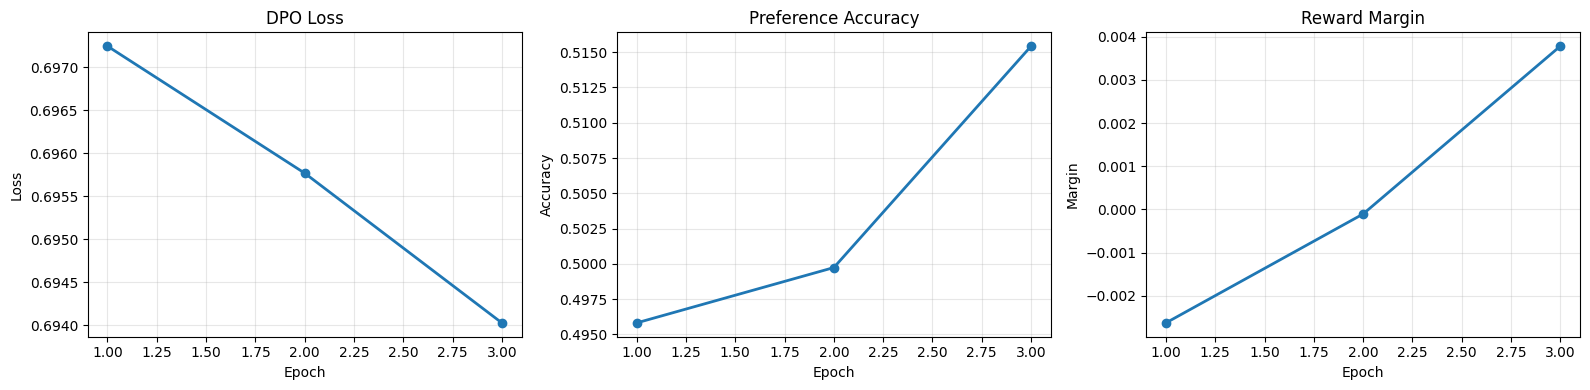


PHASE 4 COMPLETE
  Best DPO loss: 0.6940
  Final accuracy: 51.54%


In [8]:
if dpo_history:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, key, title in zip(axes, ["loss", "accuracy", "margin"],
                               ["DPO Loss", "Preference Accuracy", "Reward Margin"]):
        vals = [h[key] for h in dpo_history]
        ax.plot(range(1, len(vals)+1), vals, "o-", linewidth=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(key.title())
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "dpo_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

print("\n" + "=" * 60)
print("PHASE 4 COMPLETE")
print(f"  Best DPO loss: {best_dpo_loss:.4f}")
print(f"  Final accuracy: {dpo_history[-1]['accuracy']:.2%}" if dpo_history else "")
print("=" * 60)